<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/Kmeans_%26_hireachial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/city_lifestyle_dataset.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [35]:
df.columns

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio'],
      dtype='object')

In [36]:
num_col = df.select_dtypes(include=['number'])

In [37]:
obj_col = df.select_dtypes(include=['object'])

In [38]:
obj_col

,city_name,country
0,Old Vista,Europe
1,Beachport,Europe
2,Valleyborough,Europe
3,City,Europe
4,Falls,Europe
...,...,...
295,Old Harbor,Oceania
296,Ridgehaven,Oceania
297,North Field,Oceania
298,Bridgeford,Oceania


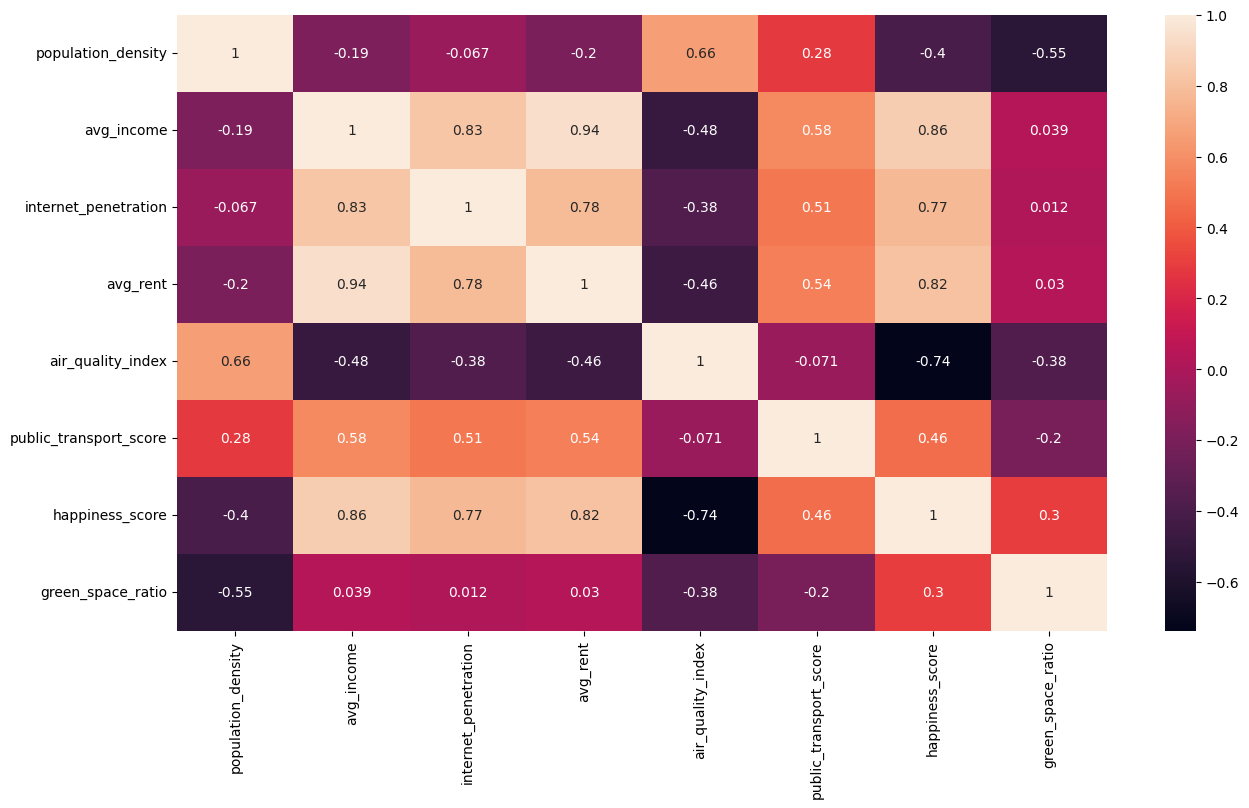

In [39]:
plt.figure(figsize=(15,8))
sns.heatmap(num_col.corr(),annot=True)
plt.show()

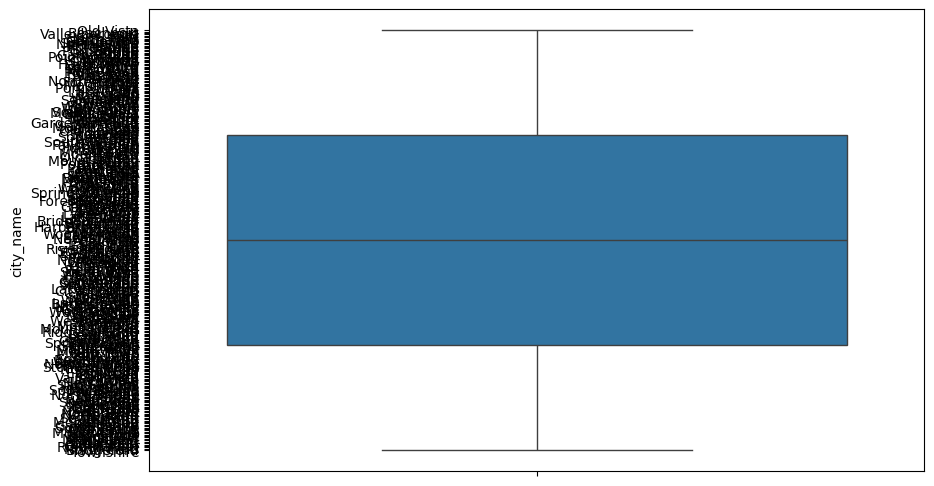

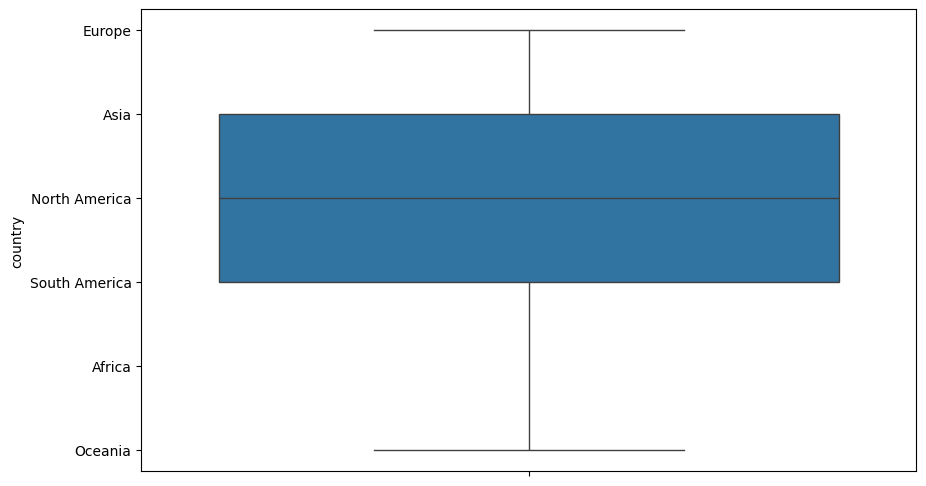

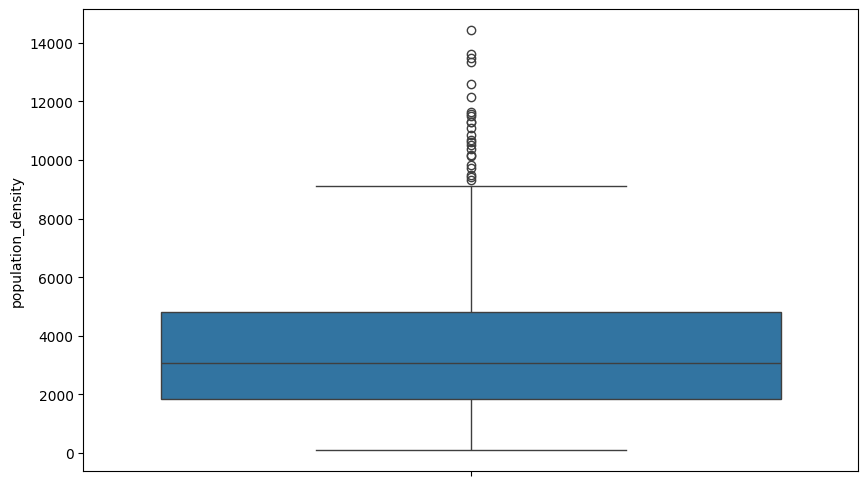

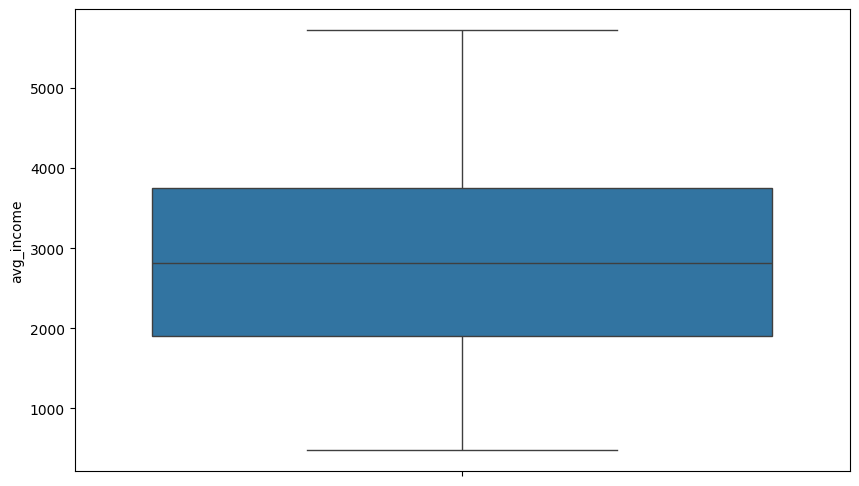

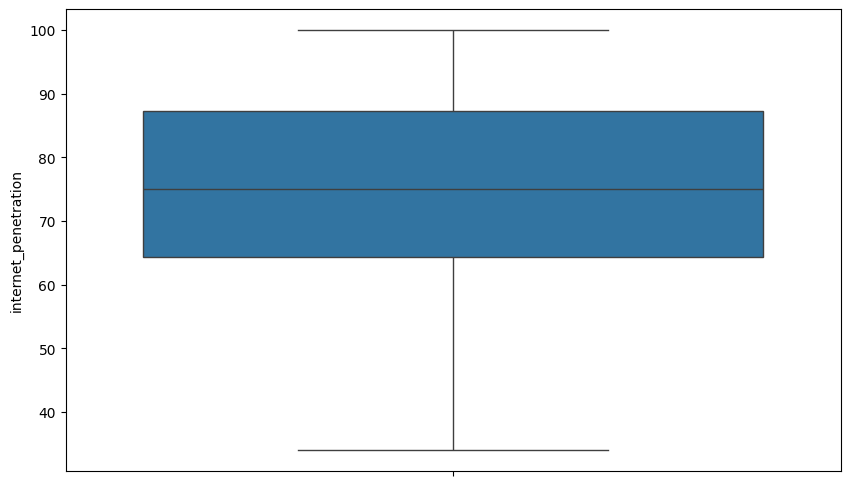

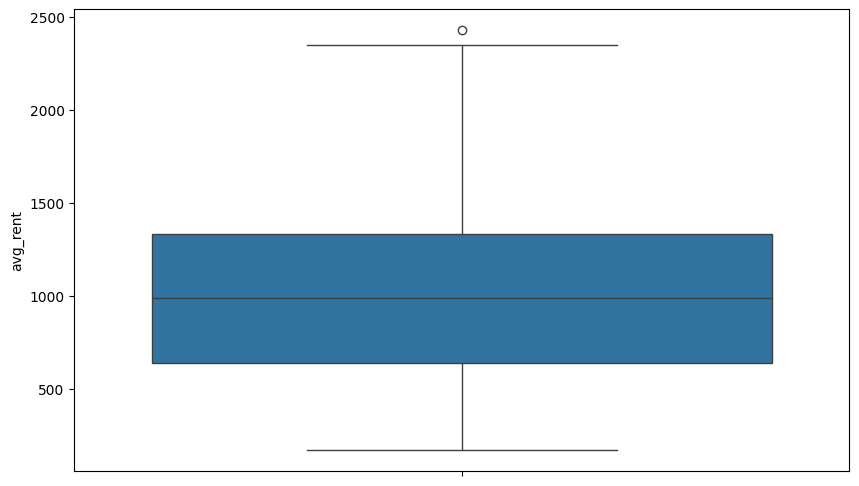

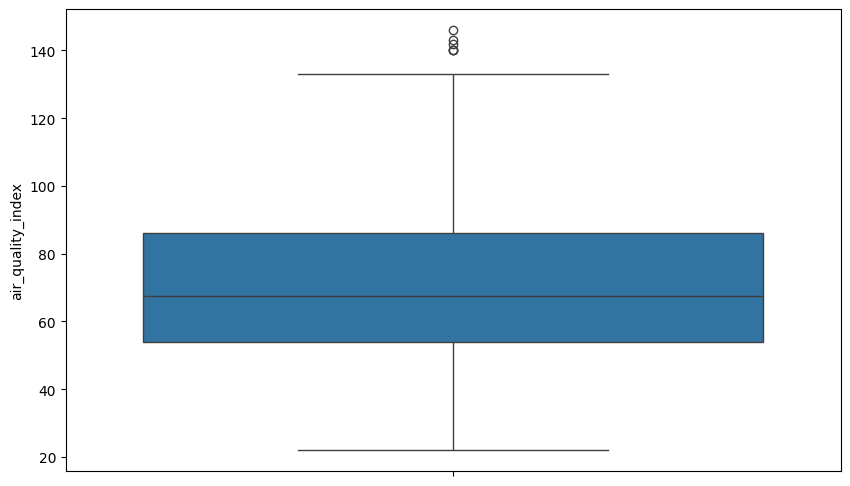

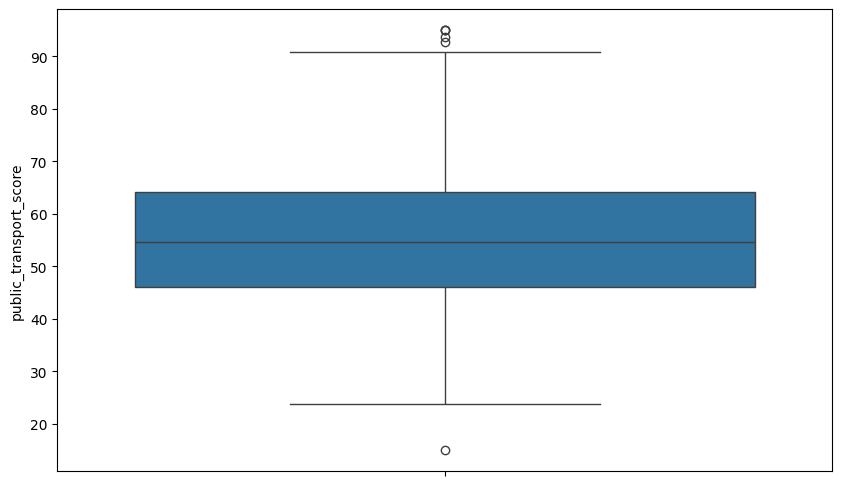

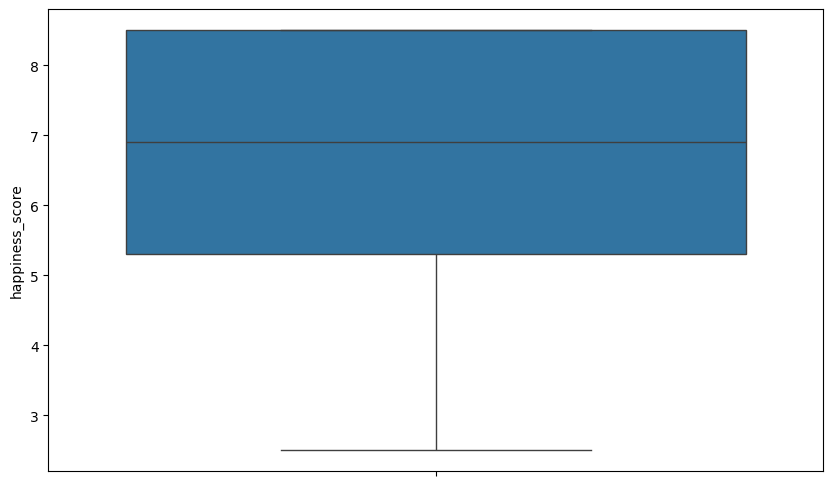

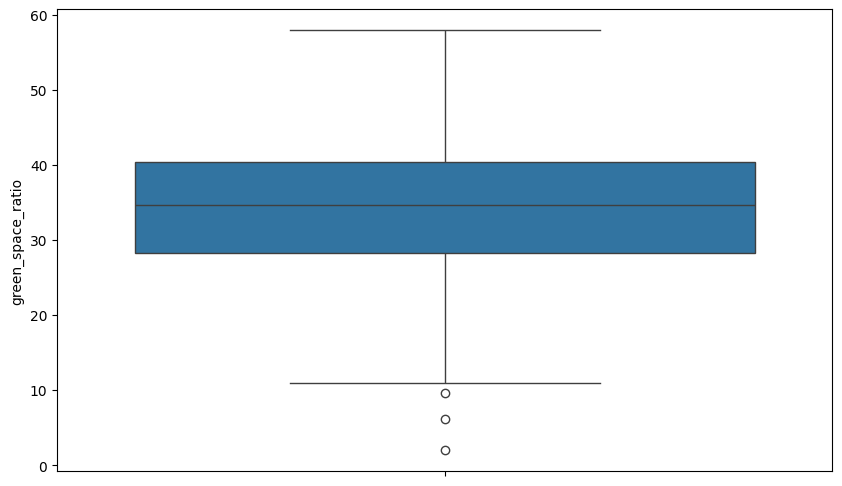

In [40]:
for col in df.columns:
  plt.figure(figsize=(10,6))
  sns.boxplot(df[col])
  plt.show()

In [49]:
num_col.drop('happiness_score',axis=1,inplace=True)

In [42]:
df.columns

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio'],
      dtype='object')

<Axes: ylabel='population_density'>

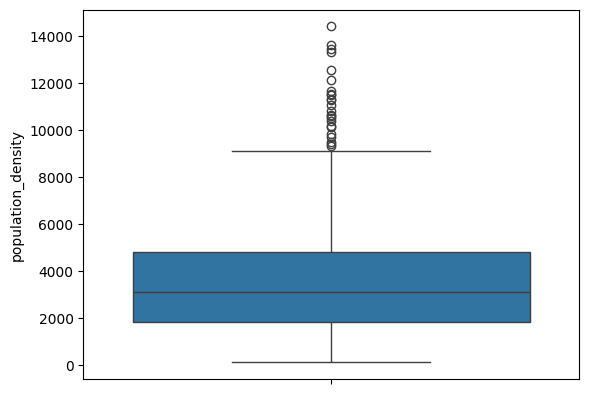

In [43]:
sns.boxplot(df['population_density'])

In [44]:
Q1 = num_col['population_density'].quantile(0.25)
Q3 = num_col['population_density'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [45]:
num_col['population_density'] = num_col['population_density'].clip(lower, upper)

In [46]:
df.columns

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio'],
      dtype='object')

<Figure size 2000x1500 with 0 Axes>

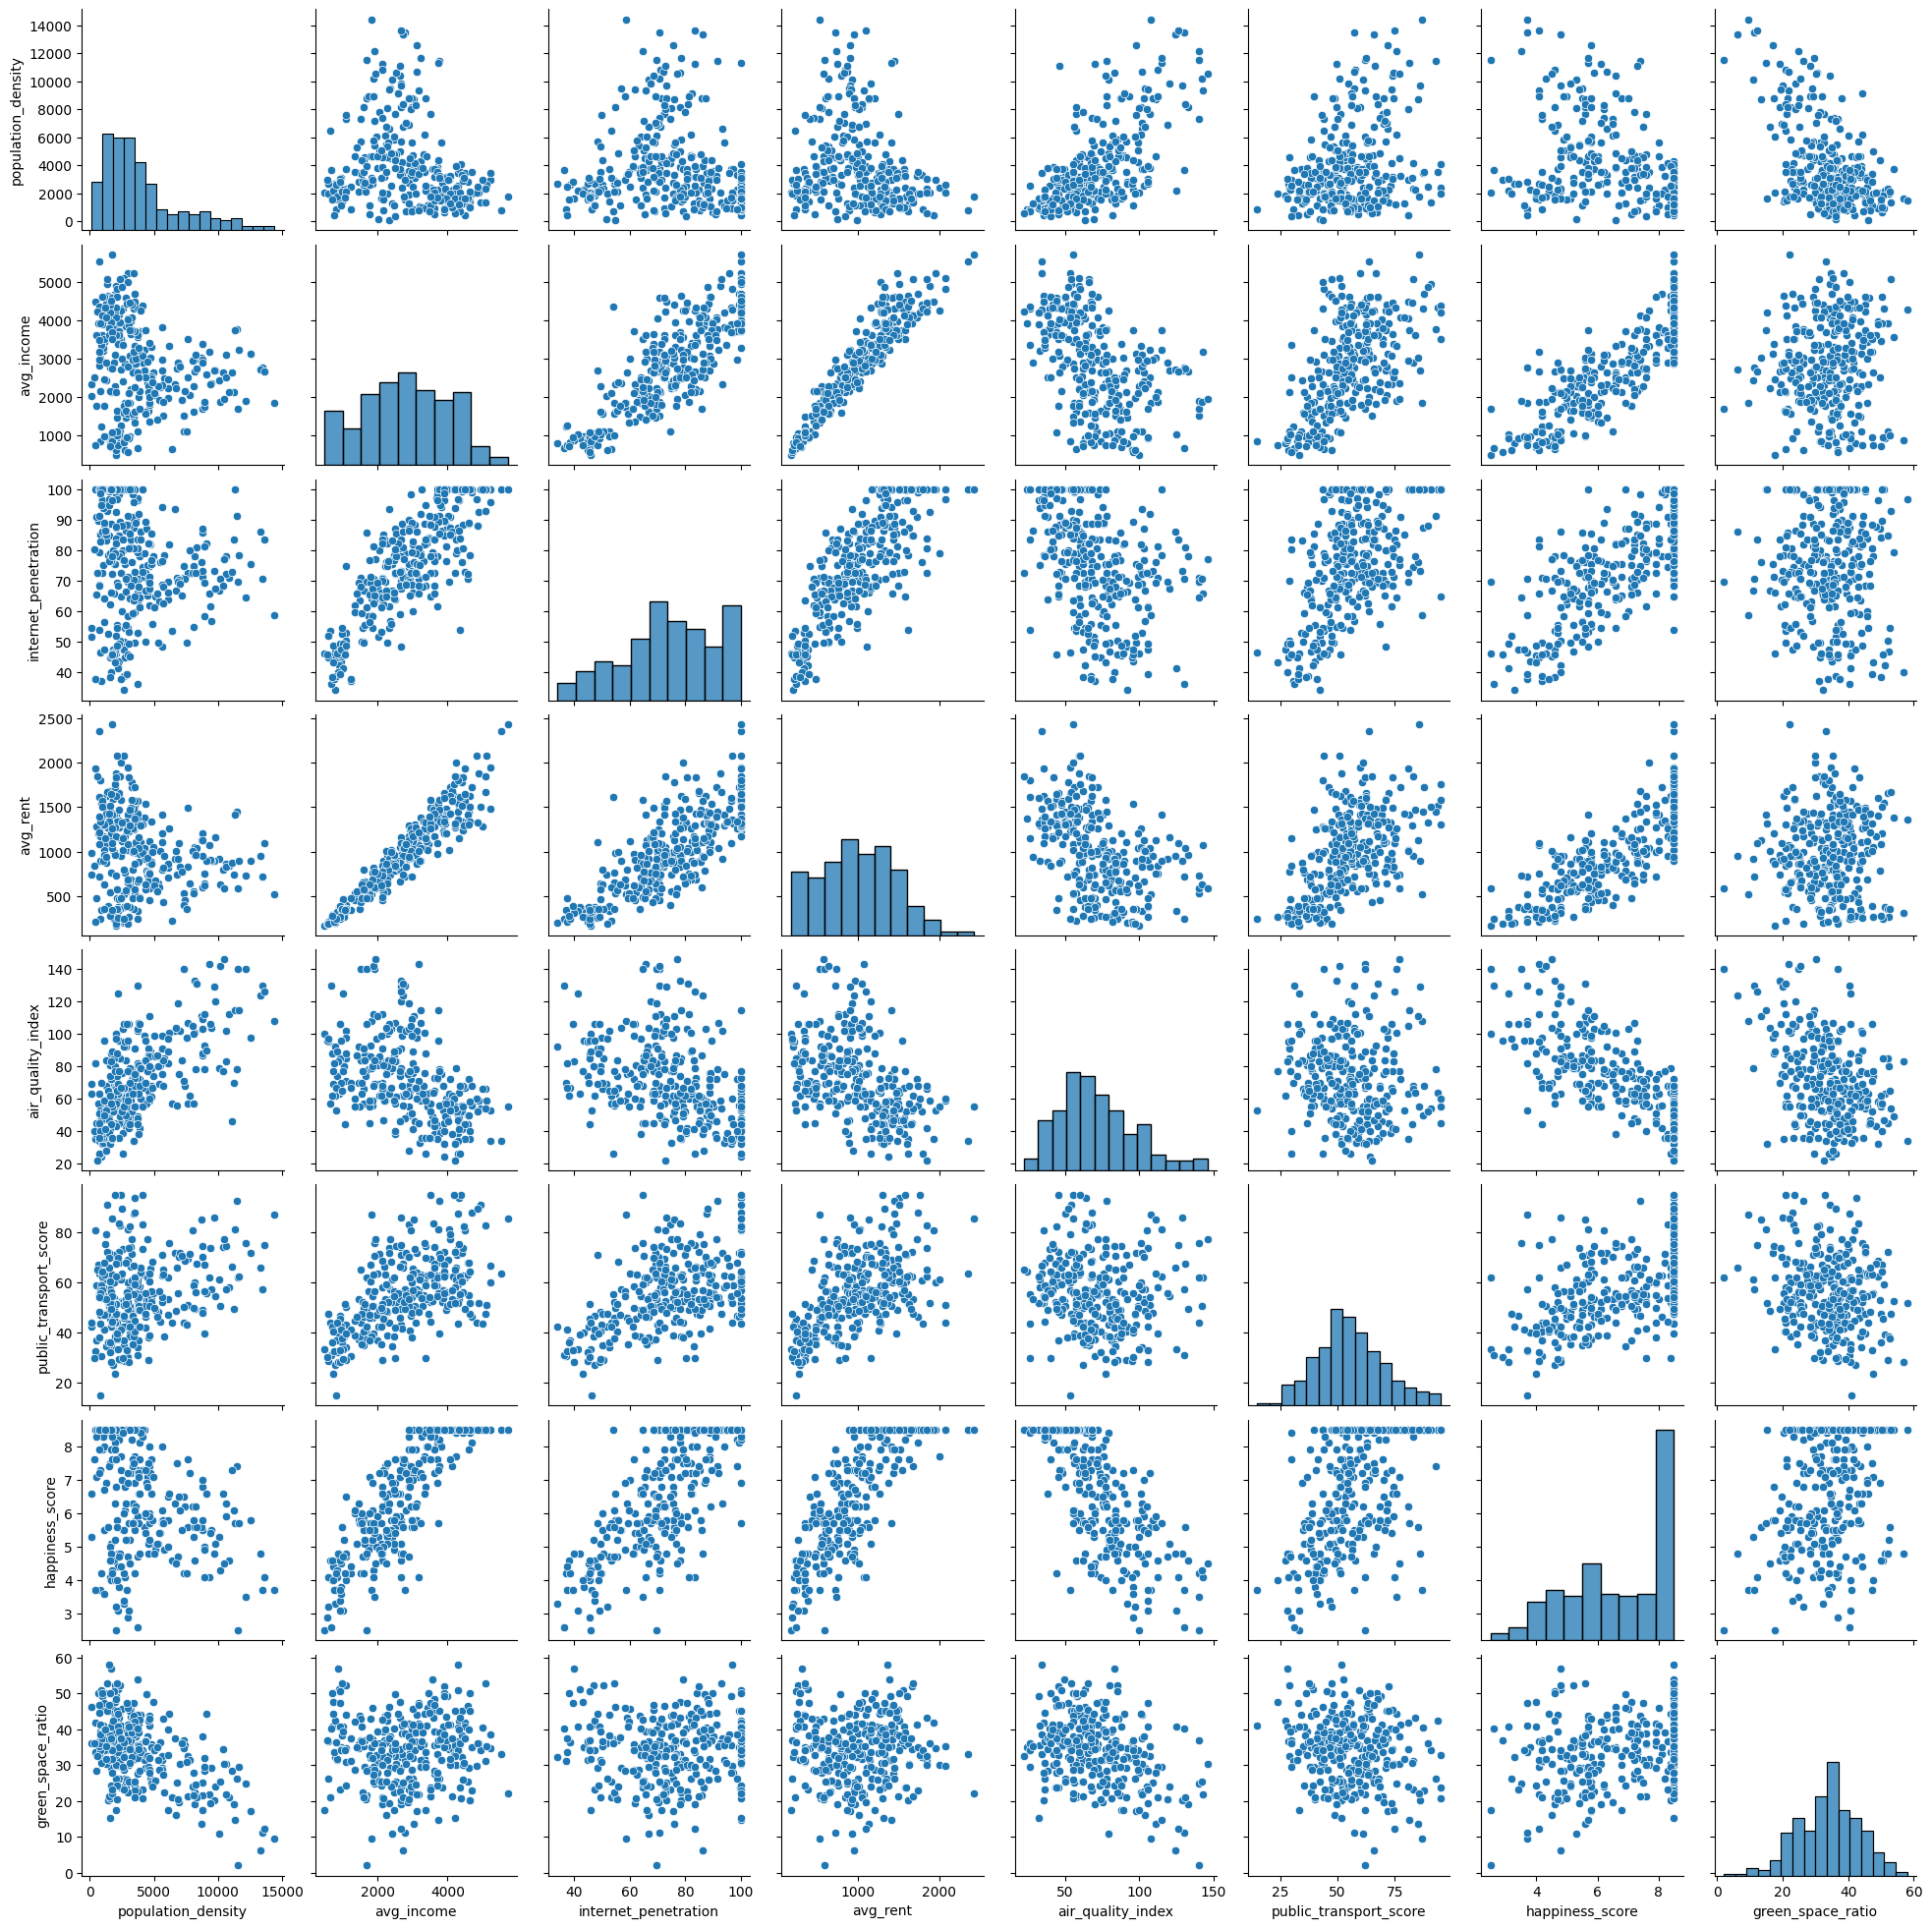

In [47]:
plt.figure(figsize = (20, 15))
sns.pairplot(df)

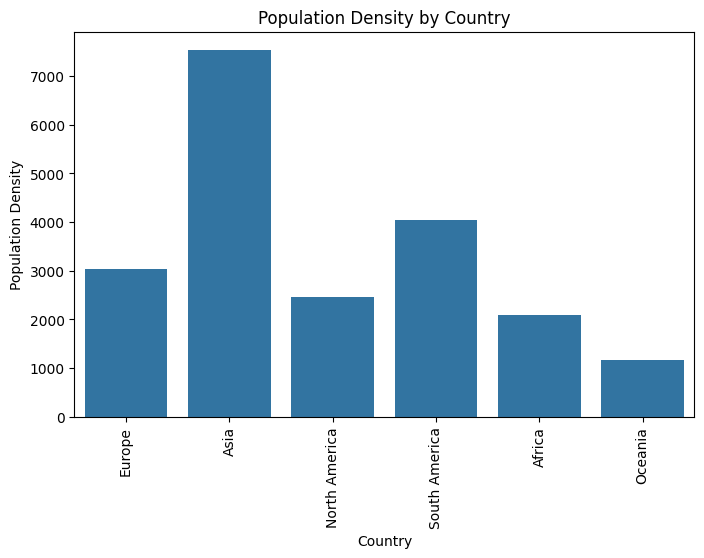

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x='country',
    y='population_density',
    data=df,
    errorbar=None   # removes those black lines
)

plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Population Density")
plt.title("Population Density by Country")

plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(num_col)

In [52]:
df_scaled = pd.DataFrame(df_scaled,columns=num_col.columns,index=num_col.index)

In [53]:
df_scaled

,population_density,avg_income,avg_rent,air_quality_index,public_transport_score,green_space_ratio
0,-0.391313,0.852930,0.674466,-1.116351,-0.253086,-1.082287
1,0.026006,0.727843,0.718372,-1.155872,0.482207,-0.094850
2,-0.473163,1.236532,0.718372,-1.274437,1.190268,0.658999
3,-0.231072,0.953000,1.047665,-0.444485,-0.443718,1.019997
4,-0.114253,1.244871,1.113524,-0.286399,2.585965,0.903203
...,...,...,...,...,...,...
295,-1.071859,1.495046,1.091571,-1.234915,0.577523,1.720758
296,-0.822850,1.394976,1.420864,-1.076829,-0.436910,0.361706
297,-1.136416,0.902965,0.740325,-1.234915,-0.001180,0.489117
298,-1.166389,0.552720,0.850089,-1.393001,-0.110113,1.126173


In [54]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
import numpy as np
from math import isnan

def hopkins(X):
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)

    rand_X = sample(range(0, n, 1), m)

    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])

    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0

    return H

In [58]:
hopkins(df_scaled)

np.float64(0.7396847528074261)

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

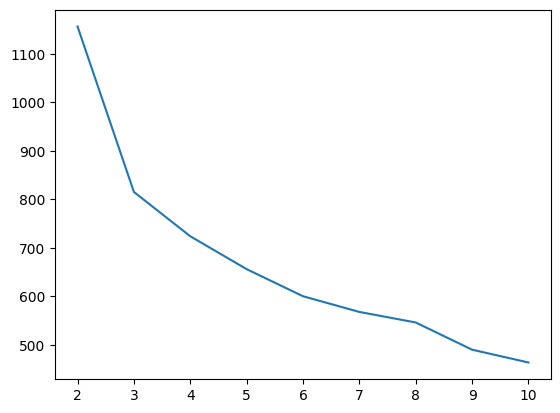

In [62]:
ssd = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k).fit(df_scaled)
    ssd.append([k,kmeans.inertia_])

ssd = pd.DataFrame(ssd)
plt.plot(ssd[0],ssd[1])

In [63]:
kmeans = KMeans(n_clusters=4,max_iter=50,random_state=0)
kmeans.fit(df_scaled)

KMeans(max_iter=50, n_clusters=4, random_state=0)

In [64]:
df['clusterid'] = kmeans.labels_

In [65]:
df['clusterid'].value_counts()

,count
clusterid,
0,84
2,75
3,72
1,69


In [66]:
df

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,clusterid
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8,0
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1,0
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2,0
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6,3
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5,0
...,...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2,0
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4,0
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6,0
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6,3


<Axes: xlabel='population_density', ylabel='avg_income'>

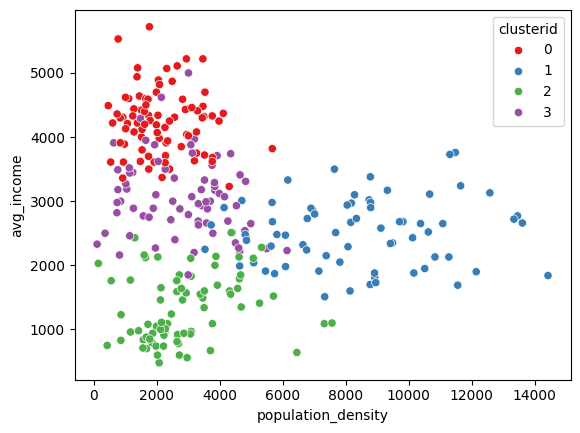

In [75]:
sns.scatterplot(x='population_density',y='avg_income',hue='clusterid',data=df,palette='Set1')

<Axes: xlabel='clusterid', ylabel='avg_income'>

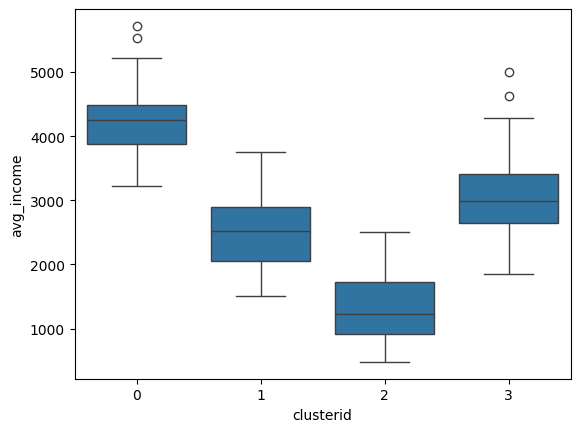

In [74]:
sns.boxplot(x='clusterid',y='avg_income',data=df)

In [76]:
df.sort_values('avg_income',ascending=False).head(15)

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,clusterid
188,Townville,North America,1763,5720,100.0,2430,55,85.6,8.5,22.2,0
187,Valley,North America,769,5530,100.0,2350,34,63.6,8.5,33.2,0
8,Springsville,Europe,2938,5220,100.0,1950,53,60.0,8.5,34.8,0
158,East Bridge,North America,3461,5220,95.7,1480,34,66.6,8.5,38.6,0
157,Fallston,North America,2645,5110,100.0,2080,59,50.9,8.5,35.3,0
178,Gardenland,North America,1388,5080,92.8,1670,54,47.4,8.5,52.9,0
163,North Wood,North America,2314,5070,100.0,1850,66,82.8,8.5,31.2,0
170,Fieldhaven,North America,3004,5000,100.0,1280,66,43.5,8.5,40.4,3
152,San Falls,North America,1369,4940,100.0,1500,54,90.9,8.5,34.3,0
140,Bridgeville,North America,2049,4890,92.7,1880,59,51.9,8.5,36.0,0


In [77]:
df.groupby('country')['avg_income'].mean()

,avg_income
country,
Africa,876.285714
Asia,2478.625000
Europe,3436.833333
North America,4176.400000
Oceania,3751.714286
South America,1821.500000


<Axes: xlabel='population_density', ylabel='avg_income'>

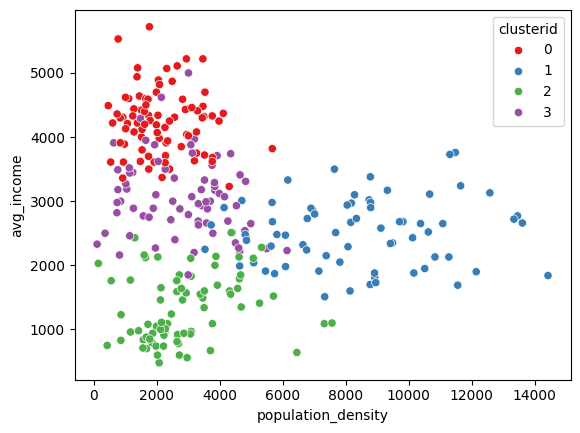

In [79]:
sns.scatterplot(
    data=df,
    x='population_density',
    y='avg_income',
    hue='clusterid',
    palette='Set1',
)

<Axes: xlabel='clusterid', ylabel='avg_rent'>

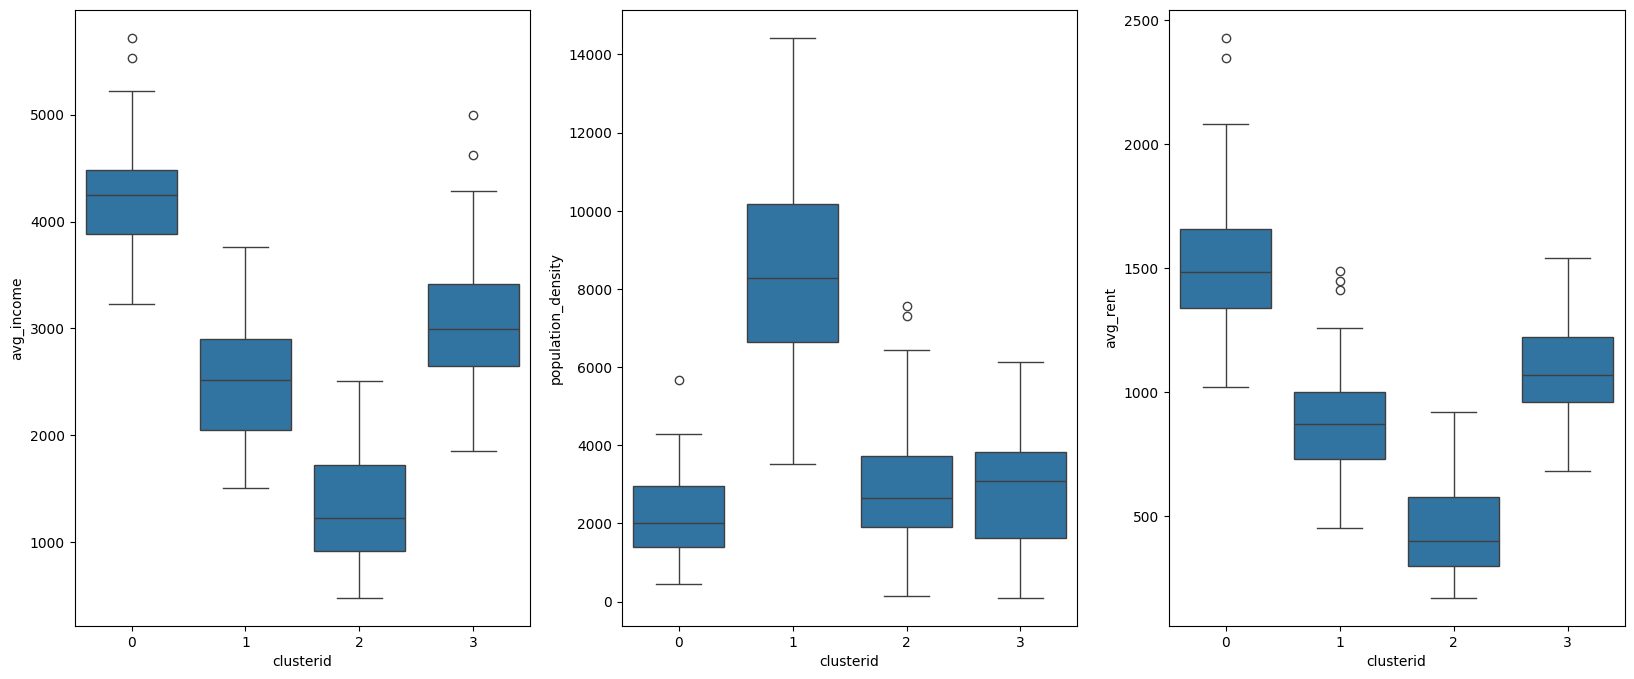

In [81]:
plt.figure(figsize = (20,8))
plt.subplot(1,3,1)
sns.boxplot(x='clusterid', y='avg_income', data= df)




plt.subplot(1,3,2)
sns.boxplot(x='clusterid', y='population_density', data= df)



plt.subplot(1,3,3)
sns.boxplot(x='clusterid', y='avg_rent', data= df)

In [88]:
mean_df = df[['avg_income', 'population_density', 'avg_rent', 'air_quality_index', 'happiness_score','clusterid']].groupby('clusterid').mean()
mean_df

,avg_income,population_density,avg_rent,air_quality_index,happiness_score
clusterid,,,,,
0,4233.571429,2174.238095,1530.714286,50.142857,8.379762
1,2515.217391,8402.797101,877.246377,97.884058,5.576812
2,1326.133333,2885.773333,451.200000,79.333333,4.838667
3,3049.027778,2841.541667,1081.666667,61.916667,7.522222


In [82]:
df.columns

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio',
       'clusterid'],
      dtype='object')

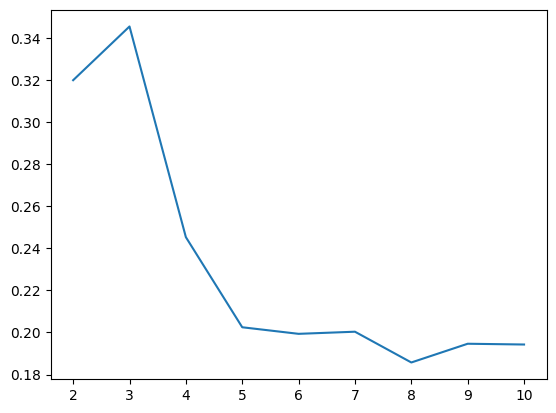

In [91]:
ss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k).fit(df_scaled)
    ss.append([k, silhouette_score(df_scaled, kmeans.labels_)])

sil = pd.DataFrame(ss)
plt.plot(sil[0],sil[1])

In [92]:
# silhouette analysis

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:

    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(df_scaled)

    cluster_labels = kmeans.labels_

    # silhouette score
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.3198618094175828
For n_clusters=3, the silhouette score is 0.3448188535571512
For n_clusters=4, the silhouette score is 0.2390863239218551
For n_clusters=5, the silhouette score is 0.21461052092292712
For n_clusters=6, the silhouette score is 0.2156258586506339
For n_clusters=7, the silhouette score is 0.19933863290359535
For n_clusters=8, the silhouette score is 0.21188845060454578


<Axes: xlabel='avg_income', ylabel='happiness_score'>

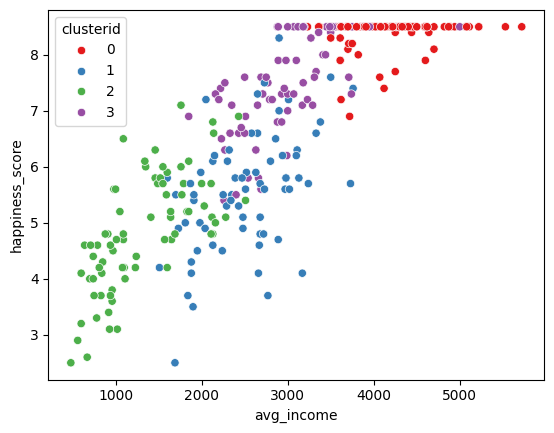

In [113]:
sns.scatterplot(x='avg_income',y='happiness_score',hue='clusterid',data=df, palette='Set1',
)

In [104]:
df.columns

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio',
       'clusterid'],
      dtype='object')

In [114]:
kmeans = KMeans(n_clusters=3,max_iter=50,random_state=0)
kmeans.fit(df_scaled)
df['clusterid_3'] = kmeans.labels_

In [115]:
df['clusterid_3'].value_counts()

,count
clusterid_3,
0,133
2,93
1,74


<Axes: xlabel='population_density', ylabel='avg_income'>

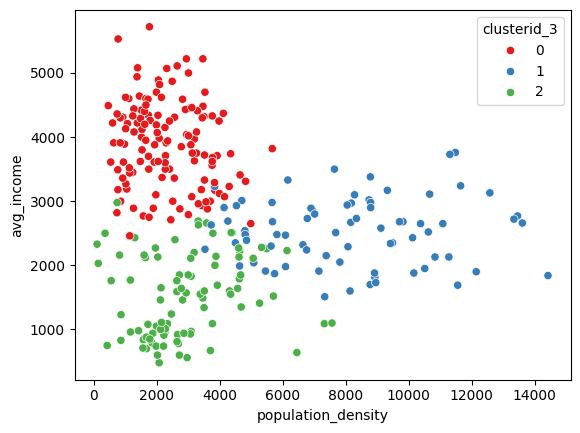

In [117]:
sns.scatterplot(
    data=df,
    x='population_density',
    y='avg_income',
    hue='clusterid_3',
    palette='Set1',
)

In [118]:
mean_df = df[['avg_income', 'population_density', 'avg_rent', 'air_quality_index', 'happiness_score','clusterid_3']].groupby('clusterid_3').mean()
mean_df

,avg_income,population_density,avg_rent,air_quality_index,happiness_score
clusterid_3,,,,,
0,3897.142857,2319.796992,1400.300752,53.135338,8.203759
1,2530.945946,8131.135135,880.540541,96.959459,5.639189
2,1532.795699,2937.806452,531.505376,76.688172,5.212903


<Axes: xlabel='country', ylabel='avg_income'>

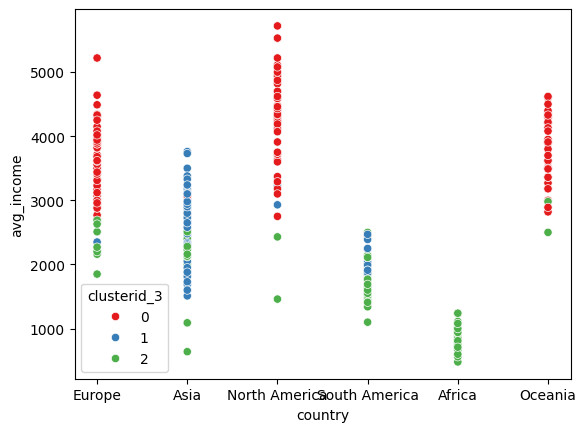

In [121]:
sns.scatterplot(
    data=df,
    x='country',
    y='avg_income',
    hue='clusterid_3',
    palette='Set1',
)

<Axes: xlabel='clusterid_3', ylabel='avg_rent'>

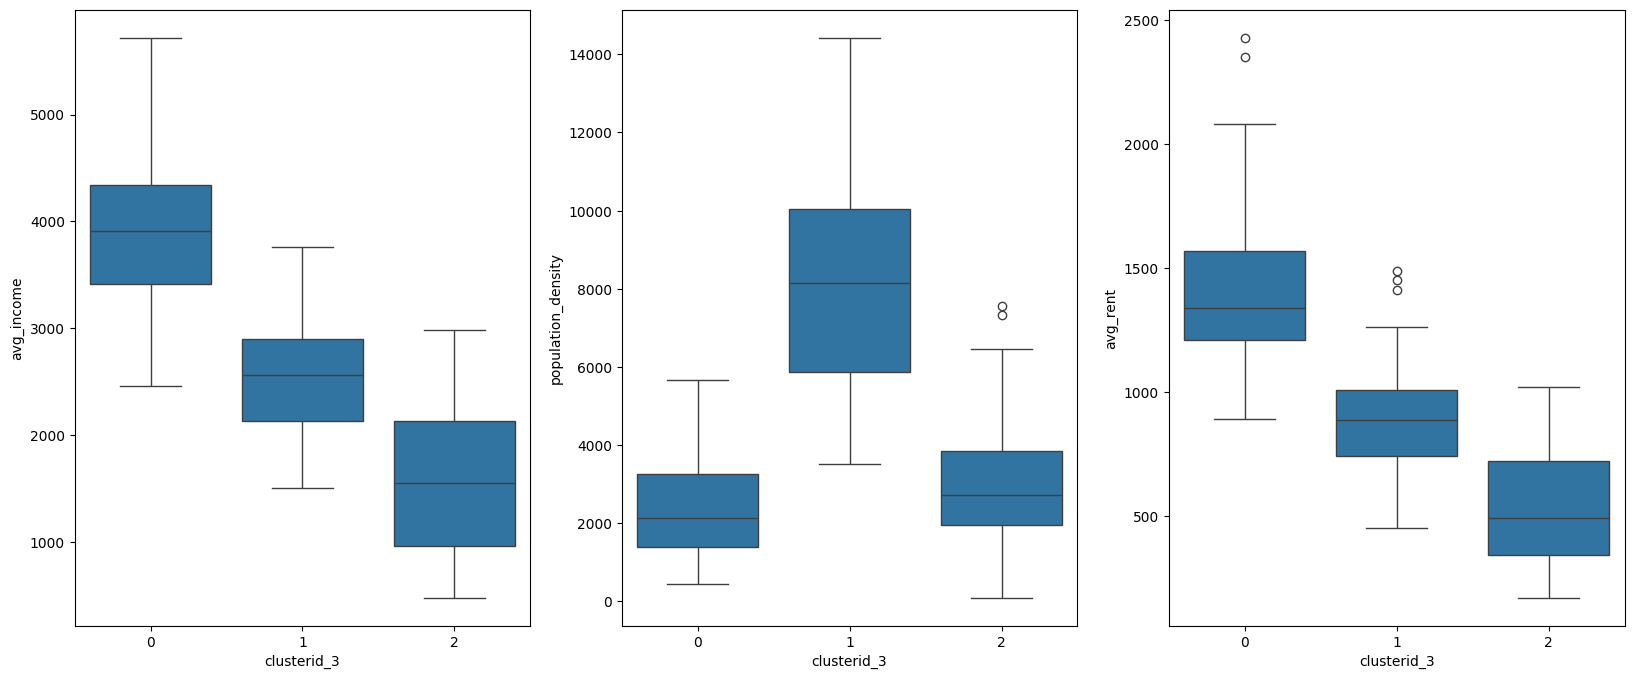

In [122]:
plt.figure(figsize = (20,8))
plt.subplot(1,3,1)
sns.boxplot(x='clusterid_3', y='avg_income', data= df)




plt.subplot(1,3,2)
sns.boxplot(x='clusterid_3', y='population_density', data= df)



plt.subplot(1,3,3)
sns.boxplot(x='clusterid_3', y='avg_rent', data= df)

In [129]:
df.sort_values(by = ['avg_income'] ,ascending =[False]).head(5)

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,clusterid,clusterid_3
188,Townville,North America,1763,5720,100.0,2430,55,85.6,8.5,22.2,0,0
187,Valley,North America,769,5530,100.0,2350,34,63.6,8.5,33.2,0,0
8,Springsville,Europe,2938,5220,100.0,1950,53,60.0,8.5,34.8,0,0
158,East Bridge,North America,3461,5220,95.7,1480,34,66.6,8.5,38.6,0,0
157,Fallston,North America,2645,5110,100.0,2080,59,50.9,8.5,35.3,0,0


In [131]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

import warnings
warnings.filterwarnings('ignore')

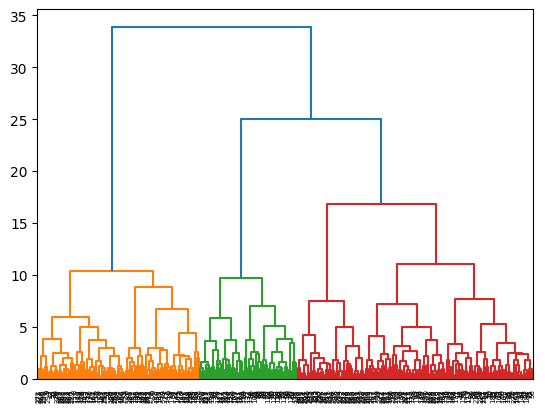

In [132]:
mergings = linkage(df_scaled, method="ward", metric='euclidean')
dendrogram(mergings)
plt.show()

In [133]:
cluster_labels_3 = cut_tree(mergings, n_clusters=3).reshape(-1, )
cluster_labels_3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1,
       1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [134]:
df['cluster_labels_3'] = cluster_labels_3
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,clusterid,clusterid_3,cluster_labels_3
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8,0,0,0
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1,0,0,0
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2,0,0,0
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6,3,0,0
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5,0,0,0


In [135]:
df.cluster_labels_3.value_counts()

,count
cluster_labels_3,
1,143
0,98
2,59


<Axes: xlabel='cluster_labels_3', ylabel='avg_rent'>

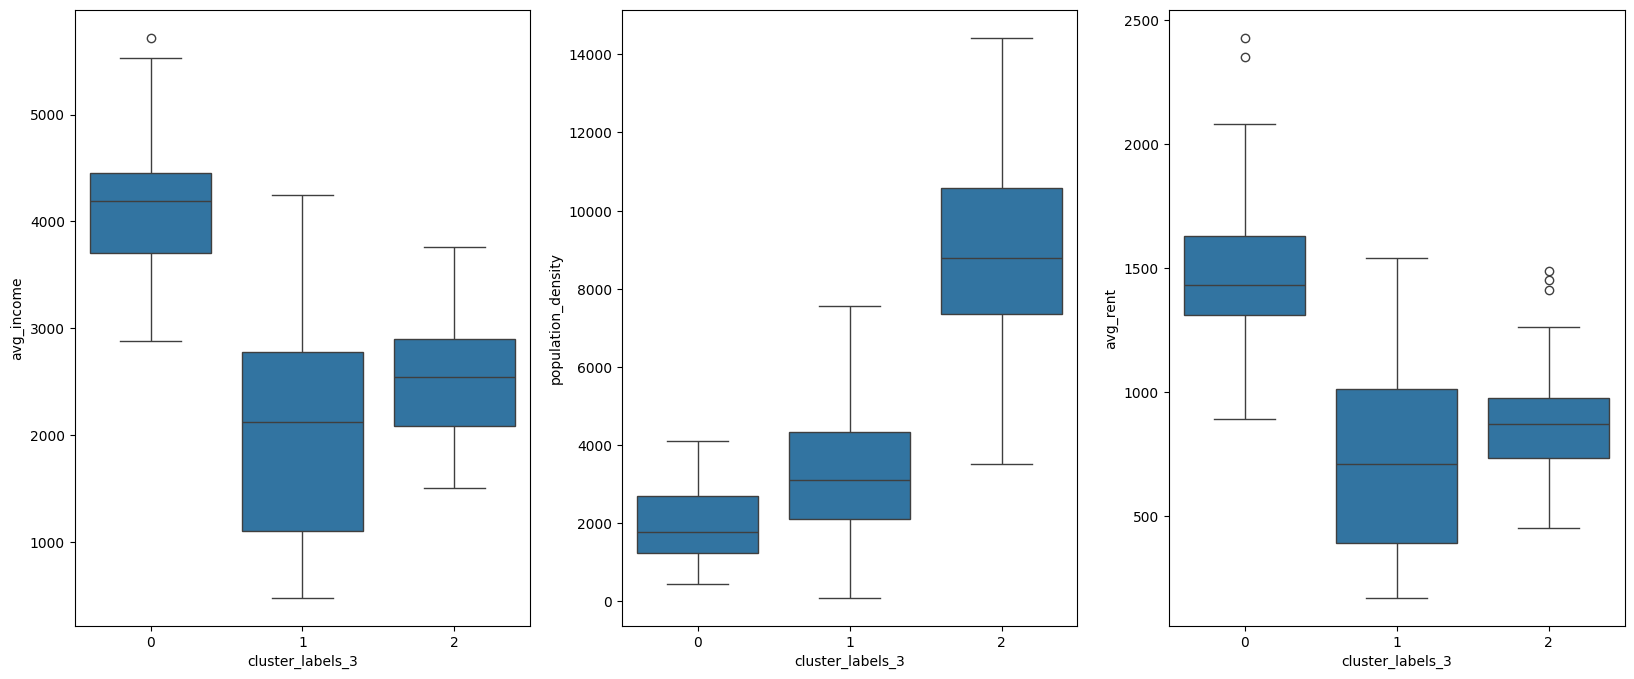

In [136]:
plt.figure(figsize = (20,8))
plt.subplot(1,3,1)
sns.boxplot(x='cluster_labels_3', y='avg_income', data= df)




plt.subplot(1,3,2)
sns.boxplot(x='cluster_labels_3', y='population_density', data= df)



plt.subplot(1,3,3)
sns.boxplot(x='cluster_labels_3', y='avg_rent', data= df)

<Axes: xlabel='avg_income', ylabel='happiness_score'>

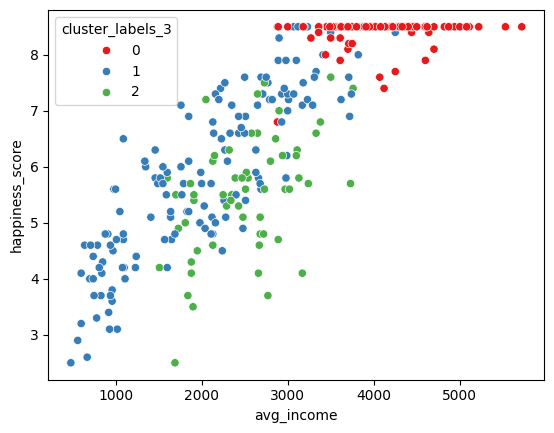

In [138]:
sns.scatterplot(x='avg_income',y='happiness_score',hue='cluster_labels_3',data=df, palette='Set1',
)

In [139]:
df.sort_values(by = ['avg_income'] ,ascending =[False]).head(5)

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,clusterid,clusterid_3,cluster_labels_3
188,Townville,North America,1763,5720,100.0,2430,55,85.6,8.5,22.2,0,0,0
187,Valley,North America,769,5530,100.0,2350,34,63.6,8.5,33.2,0,0,0
8,Springsville,Europe,2938,5220,100.0,1950,53,60.0,8.5,34.8,0,0,0
158,East Bridge,North America,3461,5220,95.7,1480,34,66.6,8.5,38.6,0,0,0
157,Fallston,North America,2645,5110,100.0,2080,59,50.9,8.5,35.3,0,0,0


In [ ]:
df.sort_values(by = ['avg_income'] ,ascending =[False]).head(5)

<Axes: xlabel='country', ylabel='avg_income'>

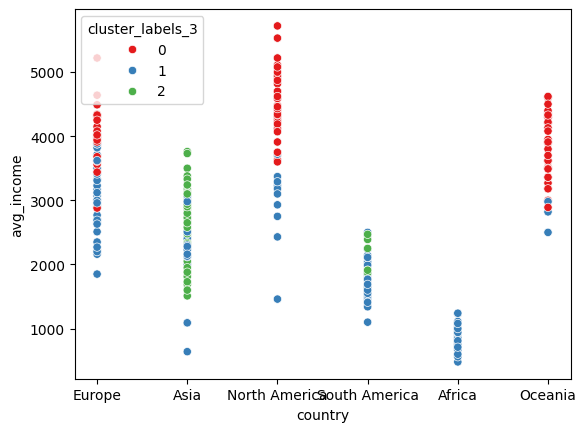

In [137]:
sns.scatterplot(
    data=df,
    x='country',
    y='avg_income',
    hue='cluster_labels_3',
    palette='Set1',
)